In [1]:
import numpy as np
import input_parameters as parmt
import matplotlib.pyplot as plt
import matplotlib.colors
from epsilon_routines import epsilon_r, kramerskronig
from binning import gen_bin_centers

mElectron = 5.1099894e5
alpha = 1.0/137.03599908

In [2]:
q = np.arange(0.01, 5, parmt.dq) #alpha me
E = np.arange(0, 50+parmt.dE, parmt.dE) #eV

#RPA
binned_eps_im = 10*np.imag(np.load('test_resources/binned_eps/cc-pvtz_pbe_6_bg1.10_5q_50E_old.npy'))
binned_eps = kramerskronig(binned_eps_im) + 1j*binned_eps_im
bin_centers = gen_bin_centers(q_max=5)
eps_6 = epsilon_r(bin_centers, binned_eps)

/home/meganhott/Research/dielectric_pyscf/epsilon_routines.py:258: RuntimeWarning: invalid value encountered in divide
  eps_r[i] = np.nansum(eps_ri, axis=0) / (N_ang_bins - np.sum(np.isnan(eps_ri).astype(int), axis=0)) #treats nans as 0, want to average over all non-nan entries


In [7]:
#RPA Kramers-Kronig 
def kk_2d(eps_im, E, n_E):
    #eps_im = np.imag(eps)
    eps_re = np.zeros((eps_im.shape[0], E.shape[0]))
    for n, En in enumerate(E):
        E_pv = np.delete(E, n) #removes Ei = En for principal value
        eps_im_pv = np.delete(eps_im, n, axis=1)[:,:n_E]

        eps_re[:,n] = 2/np.pi*parmt.dE*(np.sum(E_pv[None,:n_E] * eps_im_pv / (E_pv[None,:n_E]**2 - En**2), axis=1) - 0.5*(E_pv[None,0]*eps_im_pv[:,0]/(E_pv[None,0]**2-En**2) + E_pv[None,n_E-2]*eps_im_pv[:,-1]/(E_pv[None,n_E-2]**2-En**2))) #trapezoid rule
    return eps_re + 1

In [3]:
#DarkELF
import sys
import os
sys.path.append(os.getcwd()+'/../DarkELF')
from darkelf import darkelf, targets

darkelf_gpaw = darkelf(target='Si', filename='Si_gpaw_noLFE.dat')

 .... Loading files for Si
Loaded Si_gpaw_noLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, “Intensity of diffracted intensities,” in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554–595, https://onlinelibrary.wiley.com/doi/pdf/10.1107/97809553602060000
Loaded /home/meganhott/Research/dielectric_pyscf/../DarkELF/darkelf/../data/Si/Si_pDoS.dat for partial densi

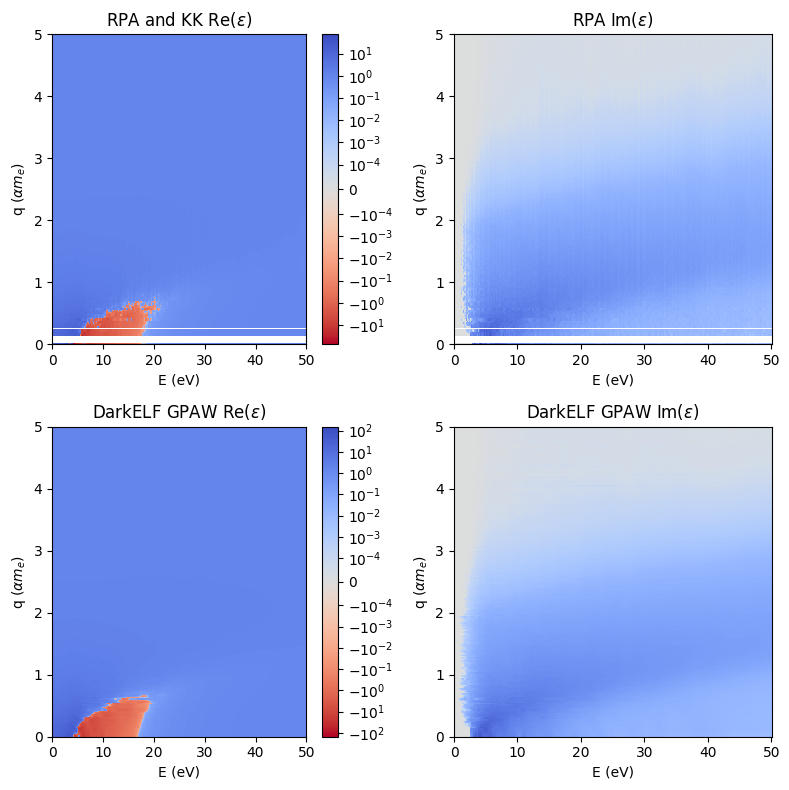

In [4]:
c = 'coolwarm_r'
th = 1e-4
re_min = np.min(np.real(eps_6[np.invert(np.isnan(eps_6))]))
re_max = np.max(np.real(eps_6[np.invert(np.isnan(eps_6))]))
im_max = np.max(np.imag(eps_6[np.invert(np.isnan(eps_6))]))
re_max = max(-1*re_min, re_max)

fig, ax = plt.subplots(2,2, figsize=(8,8))

im0 = ax[(0,0)].pcolormesh(E, q, np.real(eps_6), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
ax[(0,0)].set_title(r'RPA and KK Re($\epsilon$)')
im1 = ax[(0,1)].pcolormesh(E, q, np.imag(eps_6), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
ax[(0,1)].set_title(r'RPA Im($\epsilon$)')
im2 = ax[(1,0)].pcolormesh(E, q, darkelf_gpaw.eps1(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-re_max, vmax=re_max))
ax[(1,0)].set_title(r'DarkELF GPAW Re($\epsilon$)')
im3 = ax[(1,1)].pcolormesh(E, q, darkelf_gpaw.eps2(E, q*alpha*mElectron), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-im_max, vmax=im_max))
ax[(1,1)].set_title(r'DarkELF GPAW Im($\epsilon$)')

ax[(0,0)].set_xlim([0,50])
ax[(1,0)].set_xlim([0,50])

fig.colorbar(im0, ax=ax[(0,0)])
fig.colorbar(im1, ax=ax[(1,0)])

for i in [0,1]:
    for j in [0,1]:
        ax[(i,j)].set_xlabel('E (eV)')
        ax[(i,j)].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()

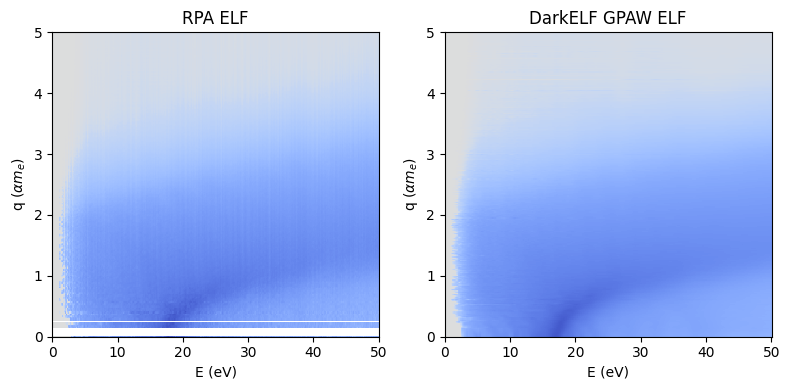

In [5]:
#ELF
fig, ax = plt.subplots(1,2, figsize=(8,4))
elf = np.imag(eps_6)/((np.imag(eps_6))**2+np.real(eps_6)**2)
elf_max = np.max(elf[np.invert(np.isnan(elf))])
im0 = ax[0].pcolormesh(E, q, elf, cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
ax[0].set_title('RPA ELF')
im1 = ax[1].pcolormesh(E, q, darkelf_gpaw.eps2(E, q*alpha*mElectron)/((darkelf_gpaw.eps2(E, q*alpha*mElectron))**2+darkelf_gpaw.eps1(E, q*alpha*mElectron)**2), cmap=c, norm=matplotlib.colors.SymLogNorm(th, vmin=-elf_max, vmax=elf_max))
#ax[1].axvline(16.7)
ax[1].set_title('DarkELF GPAW ELF')
for i in [0,1]:
    ax[i].set_xlabel('E (eV)')
    ax[i].set_ylabel(r'q ($\alpha m_e$)')
plt.tight_layout()
plt.show()

In [8]:
#Plasmon peak

def f(eps_im, E, q, wp):
    n_E = int(wp/parmt.dE)
    eps_re_wp = kk_2d(eps_im, E, n_E)
    eps_wp = eps_im + 1j*eps_re_wp

    elf = eps_im/((eps_im)**2+eps_re_wp**2)
    elf[np.isnan(elf)] = 0 #set nans to 0

    f = parmt.dq*(np.sum(elf/q[:,None], axis=0) - 0.5*(elf[0]/q[0,None] + elf[-1]/q[-1,None])) #trapezoid rule for q integration
    return f


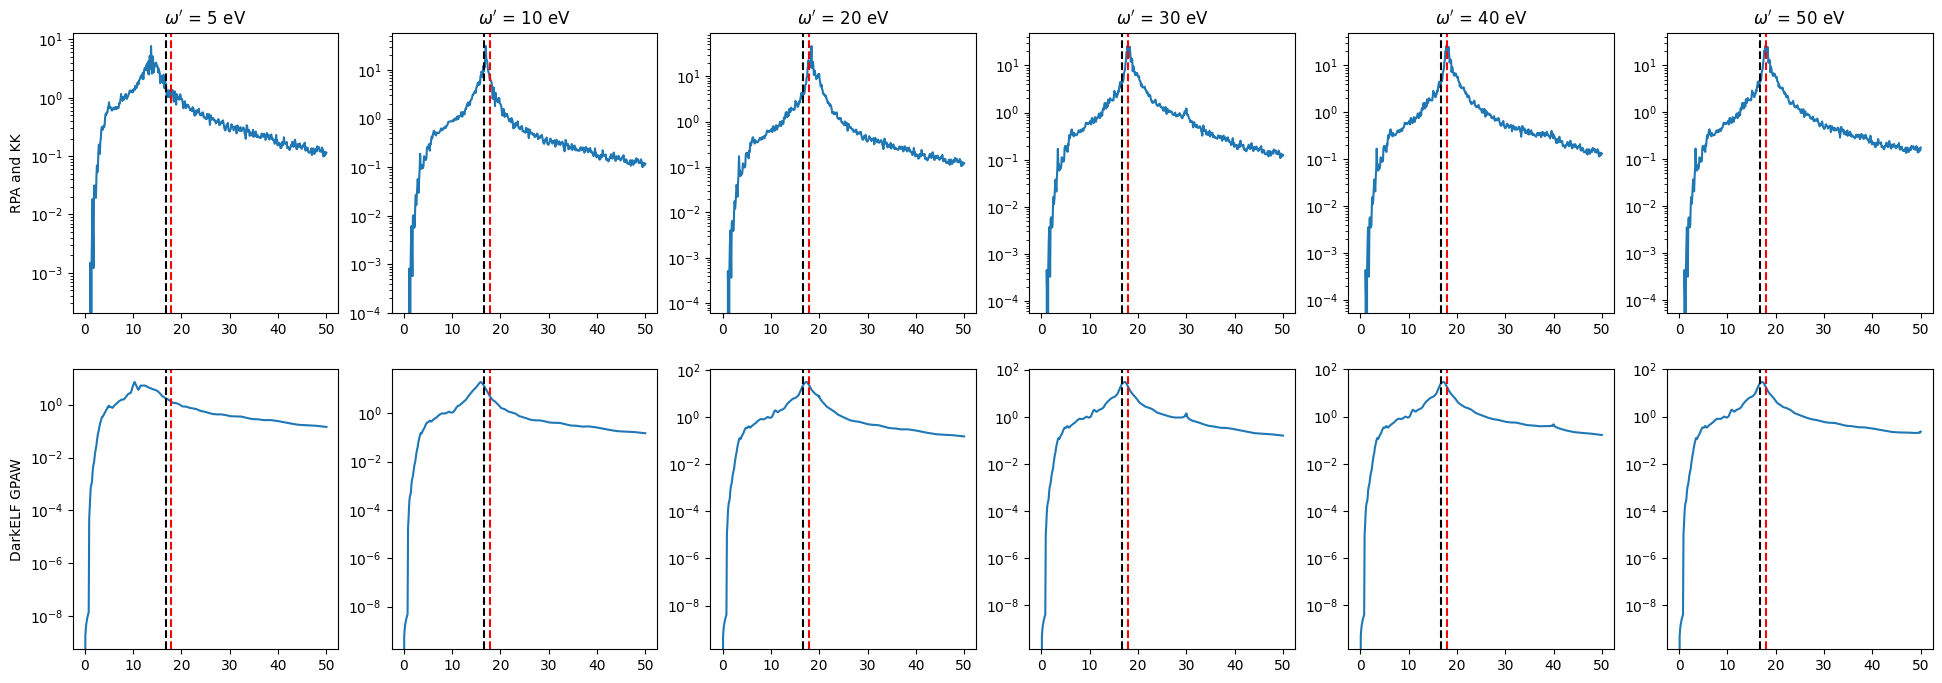

In [13]:
wp = [5, 10, 20, 30, 40, 50]
fig, ax = plt.subplots(2, len(wp), figsize=(4*len(wp),8))
#im0 = ax[0].pcolormesh(E, q, f(eps_6_im, E, q, 10, corr=True), norm=matplotlib.colors.SymLogNorm(1e-6))
#im0 = ax[1].pcolormesh(E, q, f(eps_6_im, E, q, 200, corr=True), norm=matplotlib.colors.SymLogNorm(1e-6))
for i,w in enumerate(wp): 
    ax[(0,i)].plot(E, f(np.imag(eps_6), E, q, w))
    ax[(0,i)].set_yscale('log')
    ax[(0,i)].set_title(fr"$\omega'$ = {w} eV")
    ax[(0,i)].axvline(16.7, color='k', linestyle='--')
    ax[(0,i)].axvline(17.9, color='r', linestyle='--')
    ax[(1,i)].plot(E, f(darkelf_gpaw.eps2(E, q*alpha*mElectron), E, q, w))
    ax[(1,i)].set_yscale('log')
    ax[(1,i)].axvline(16.7, color='k', linestyle='--')
    ax[(1,i)].axvline(17.9, color='r', linestyle='--')
ax[(0,0)].set_ylabel('RPA and KK')
ax[(1,0)].set_ylabel('DarkELF GPAW')
plt.show()

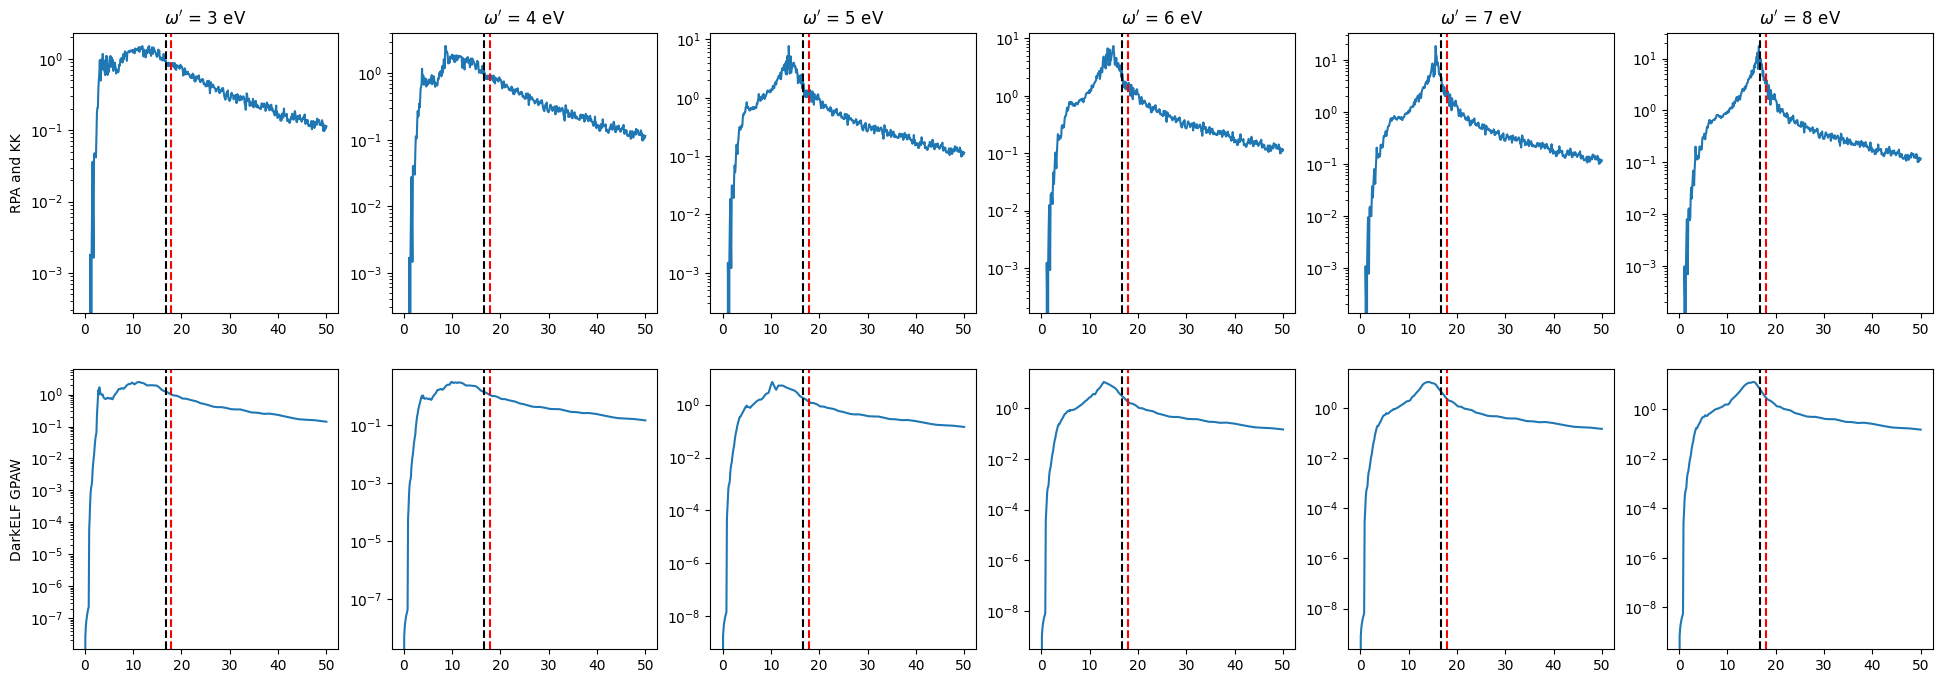

In [14]:
wp = [3,4,5,6,7,8]
fig, ax = plt.subplots(2, len(wp), figsize=(4*len(wp),8))
#im0 = ax[0].pcolormesh(E, q, f(eps_6_im, E, q, 10, corr=True), norm=matplotlib.colors.SymLogNorm(1e-6))
#im0 = ax[1].pcolormesh(E, q, f(eps_6_im, E, q, 200, corr=True), norm=matplotlib.colors.SymLogNorm(1e-6))
for i,w in enumerate(wp): 
    ax[(0,i)].plot(E, f(np.imag(eps_6), E, q, w))
    ax[(0,i)].set_yscale('log')
    ax[(0,i)].set_title(fr"$\omega'$ = {w} eV")
    ax[(0,i)].axvline(16.7, color='k', linestyle='--')
    ax[(0,i)].axvline(17.9, color='r', linestyle='--')
    ax[(1,i)].plot(E, f(darkelf_gpaw.eps2(E, q*alpha*mElectron), E, q, w))
    ax[(1,i)].set_yscale('log')
    ax[(1,i)].axvline(16.7, color='k', linestyle='--')
    ax[(1,i)].axvline(17.9, color='r', linestyle='--')
ax[(0,0)].set_ylabel('RPA and KK')
ax[(1,0)].set_ylabel('DarkELF GPAW')
plt.show()

$$\displaystyle f(\omega) = \int \frac{dq}{q} \text{Im}\left[\frac{-1}{\epsilon_{\omega'}(\omega, q)}\right], \quad \text{Re}[\epsilon_{\omega'}(\omega, q)] = 1 + \int_{-\omega'}^{\omega'} d\omega'' \frac{\text{Im}[\epsilon^{\text{RPA/GPAW}}(\omega'', q)]}{\omega - \omega''}, \quad \text{Im}[\epsilon_{\omega'}(\omega, q)] = \text{Im}[\epsilon^{\text{RPA/GPAW}}(\omega, q)]$$